In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 5)
%matplotlib inline

## **Load the Iris Dataset**

The `load_iris(return_X_y=True)` function loads the Iris dataset and returns:

- **`X`**: A feature matrix containing four numerical features:
  - Sepal Length (cm)
  - Sepal Width (cm)
  - Petal Length (cm)
  - Petal Width (cm)

- **`y`**: A target vector containing the encoded class labels:
  - **0** → Setosa
  - **1** → Versicolor
  - **2** → Virginica

This dataset is commonly used to demonstrate multiclass classification algorithms in machine learning.

In [2]:
# Import the Pandas library for data manipulation and analysis
import pandas as pd

# Import the Iris dataset from scikit-learn
# The Iris dataset is a built-in multiclass classification dataset
from sklearn.datasets import load_iris

# Load the complete Iris dataset as a Bunch object
iris = load_iris()

# Load only the feature matrix (X) and target labels (y)
# X -> Independent features
# y -> Target labels
X, y = load_iris(return_X_y=True)

# Retrieve the names of the input features
# ['sepal length (cm)', 'sepal width (cm)',
#  'petal length (cm)', 'petal width (cm)']
feature_names = iris.feature_names

# Retrieve the names of the target classes
# ['setosa', 'versicolor', 'virginica']
target_names = iris.target_names

# Create a Pandas DataFrame from the feature matrix
# Each row represents one flower, and each column represents one feature
df = pd.DataFrame(X, columns=feature_names)

# Convert the numeric target labels (0, 1, 2)
# into their corresponding flower species names
# This makes the dataset easier to read and visualize
df['species'] = pd.Categorical.from_codes(y, target_names)

# Display the feature names
print("Feature names:", feature_names)

# Display the target class names
print("Target classes:", list(target_names))

# Display the first five rows of the dataset
df.head()

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
print("Class distribution:")
print(df['species'].value_counts())

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


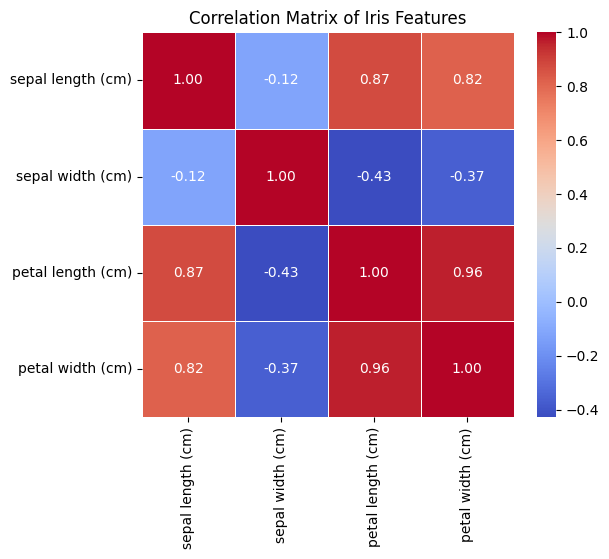

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix using only numerical columns
corr_matrix = df.drop(columns='species').corr()

# Plot the correlation heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Iris Features')
plt.show()

**Observations**

- **Petal Length** and **Petal Width** have a **very strong positive correlation**, indicating that flowers with longer petals tend to have wider petals.
- **Sepal Length** is positively correlated with both petal features, but the relationship is moderate.
- **Sepal Width** has a weak or negative correlation with the other features, making it the least correlated feature in the dataset.
- No pair of features shows perfect correlation, meaning each feature contributes unique information.

### **Conclusion**

The correlation matrix confirms that **Petal Length** and **Petal Width** are the most strongly related features. This supports the observations from the pair plot, where these features provided the clearest separation between the three Iris species.

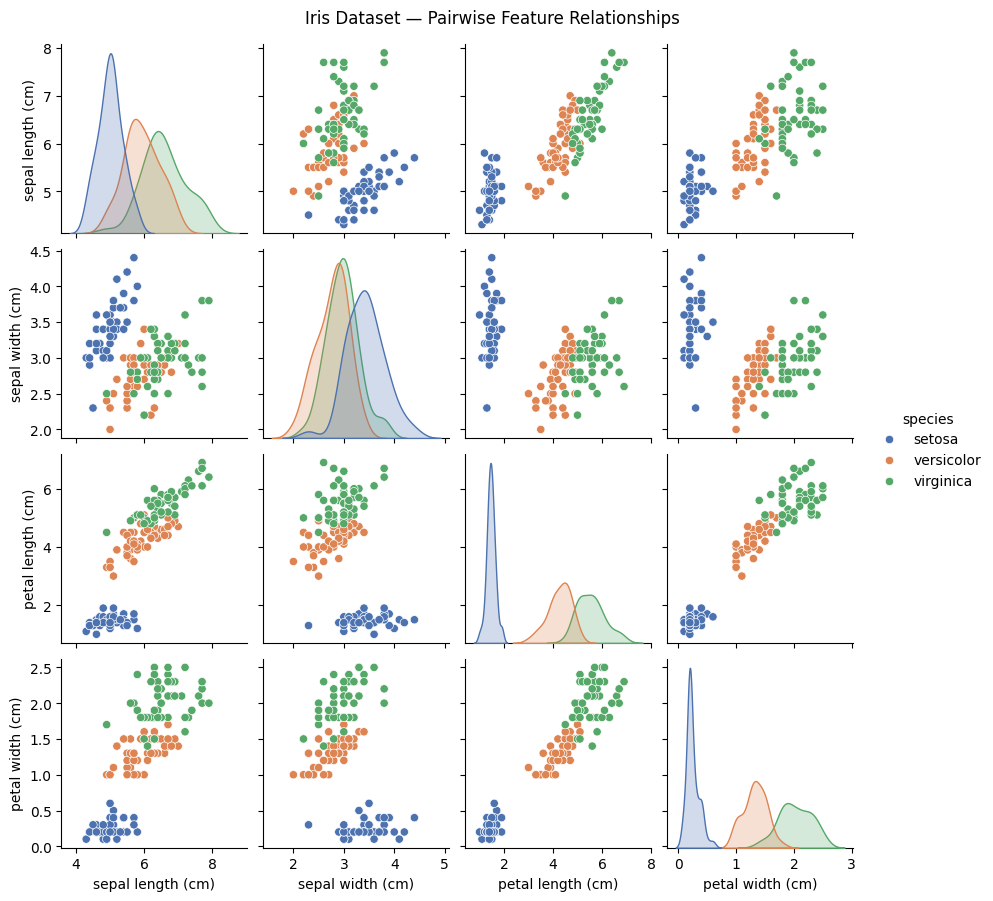

In [6]:
sns.pairplot(df, hue='species', palette='deep', height=2.2)
plt.suptitle('Iris Dataset — Pairwise Feature Relationships', y=1.02)
plt.show()

### **Parameters**

- **`df`** – The Iris DataFrame containing the feature columns and target class.
- **`hue='species'`** – Colors the data points according to the flower species (`setosa`, `versicolor`, and `virginica`).
- **`palette='deep'`** – Uses Seaborn's **Deep** color palette for better visualization.
- **`height=2.2`** – Sets the height (in inches) of each subplot.
- **`plt.suptitle()`** – Adds an overall title to the entire figure.
- **`y=1.02`** – Adjusts the title position so it doesn't overlap with the plots.

## **Observations**

### 1. Setosa is Easily Separable

The **Setosa** species (blue) forms a distinct cluster in almost every scatter plot. There is little to no overlap with the other two species, making it the easiest class to classify.

---

### 2. Versicolor and Virginica Overlap

The **Versicolor** (orange) and **Virginica** (green) species overlap in several feature combinations, especially those involving the sepal features. This makes them more challenging to distinguish.

---

### 3. Petal Features Provide Better Class Separation

The scatter plots involving **Petal Length** and **Petal Width** show clear separation among the three species. These features are the most informative for classification.

---

### 4. Strong Positive Correlation Between Petal Length and Petal Width

The plot of **Petal Length vs Petal Width** shows a strong positive linear relationship. As petal length increases, petal width also increases.

---

### 5. Sepal Length is Moderately Correlated with Petal Features

Sepal Length shows a positive relationship with both Petal Length and Petal Width, although the correlation is weaker compared to the relationship between the two petal features.

---

### 6. Sepal Width is the Least Informative Feature

Sepal Width exhibits considerable overlap among the three species and does not clearly separate the classes. It has the weakest relationship with the other features.

---

### 7. Feature Distributions

The diagonal plots display the distribution of each feature:

- **Petal Length** and **Petal Width** have well-separated distributions for each species.
- **Sepal Length** shows moderate overlap.
- **Sepal Width** has the greatest overlap among the three species.

---

### 8. No Significant Outliers

Most observations are clustered within expected ranges, and there are no extreme outliers that could negatively impact model training.

---

## **Conclusion**

From the pair plot, we can conclude that:

- **Petal Length** and **Petal Width** are the most important features for distinguishing Iris species.
- **Setosa** is easily separable from the other species.
- **Versicolor** and **Virginica** have overlapping regions, particularly when using sepal measurements.
- The strong relationship between petal features makes the Iris dataset well-suited for classification algorithms such as **Naive Bayes**, **Logistic Regression**, **K-Nearest Neighbors (KNN)**, and **Support Vector Machines (SVM)**.

Notice how `petal length` and `petal width` separate the three species almost perfectly on their own — this is a strong hint that Naive Bayes (or honestly, most classifiers) should do very well on this dataset.

## **Train/Test Split**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (105, 4)
X_test shape : (45, 4)


## **Why Gaussian Naive Bayes?**

The Iris dataset contains **continuous numerical features**, such as:

- Sepal Length (cm)
- Sepal Width (cm)
- Petal Length (cm)
- Petal Width (cm)

These features are measured as decimal values (for example, **5.1 cm** or **3.5 cm**), not as categories or text.

**Gaussian Naive Bayes (`GaussianNB`)** is designed to work with continuous numerical data. It assumes that the values of each feature for every class follow a **Gaussian (Normal or Bell-shaped) distribution**.

Since flower measurements are continuous values and are often approximately normally distributed, **Gaussian Naive Bayes is an appropriate choice for the Iris dataset.**

> **In simple terms:** Because the Iris dataset contains numerical measurements, `GaussianNB` is the most suitable Naive Bayes algorithm for this classification problem.

In [8]:
# Import the Gaussian Naive Bayes classifier
# GaussianNB is used for classification problems with continuous numerical features
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score

# Create an instance of the Gaussian Naive Bayes classifier
gnb = GaussianNB()

# Train (fit) the model using the training data
# The model learns the relationship between the input features (X_train)
# and their corresponding target labels (y_train)
gnb.fit(X_train, y_train)

# Use the trained model to predict the class labels
# for the unseen test data
y_pred = gnb.predict(X_test)

# Calculate and display the model's accuracy
# Accuracy = (Number of Correct Predictions / Total Predictions) × 100
# The result is displayed with 3 decimal places
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

Accuracy: 0.911


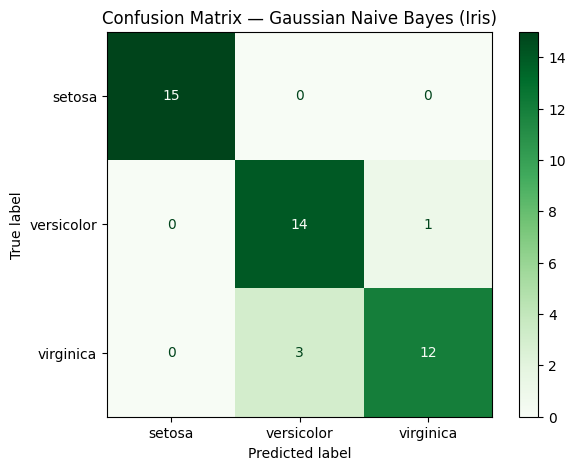

In [9]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(cmap='Greens')
plt.title('Confusion Matrix — Gaussian Naive Bayes (Iris)')
plt.show()

## **Confusion Matrix Analysis**

A **Confusion Matrix** is used to evaluate the performance of a classification model. It compares the **actual class labels** with the **predicted class labels**.

- **Rows** represent the **actual (true) classes**.
- **Columns** represent the **predicted classes**.
- **Diagonal values** represent **correct predictions**.
- **Off-diagonal values** represent **incorrect predictions (misclassifications)**.

---

## **Interpretation of the Confusion Matrix**

### 1. Setosa

- **15** Setosa flowers were correctly classified as **Setosa**.
- There were **no misclassifications**.

**Accuracy for Setosa:** **15/15 (100%)**

---

### 2. Versicolor

- **14** Versicolor flowers were correctly classified.
- **1** Versicolor flower was incorrectly classified as **Virginica**.

This indicates that the model performs well for Versicolor but makes a small number of mistakes.

---

### 3. Virginica

- **12** Virginica flowers were correctly classified.
- **3** Virginica flowers were incorrectly classified as **Versicolor**.

Most of the classification errors occur between **Versicolor** and **Virginica**.

---

## **Why Does This Happen?**

From the pair plot and correlation analysis, we observed that:

- **Setosa** has clearly different feature values, making it easy to classify.
- **Versicolor** and **Virginica** have overlapping feature values, especially in the sepal measurements.

Because of this overlap, the model sometimes confuses these two species.

---

## **Overall Performance**

- Total test samples = **45**
- Correct predictions = **41**
- Incorrect predictions = **4**

The accuracy is calculated as:

$$
\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}} \times 100
$$

Substituting the values:

$$
\text{Accuracy} = \frac{41}{45} \times 100 = 91.11\%
$$

This confusion matrix shows that the **Gaussian Naive Bayes model performs very well on the Iris dataset**, with most predictions being correct. The only noticeable errors occur between **Versicolor** and **Virginica**, as their features are more similar than those of **Setosa**.

In [10]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



## **Inspecting `predict_proba()` — Understanding How Naive Bayes Makes Predictions**


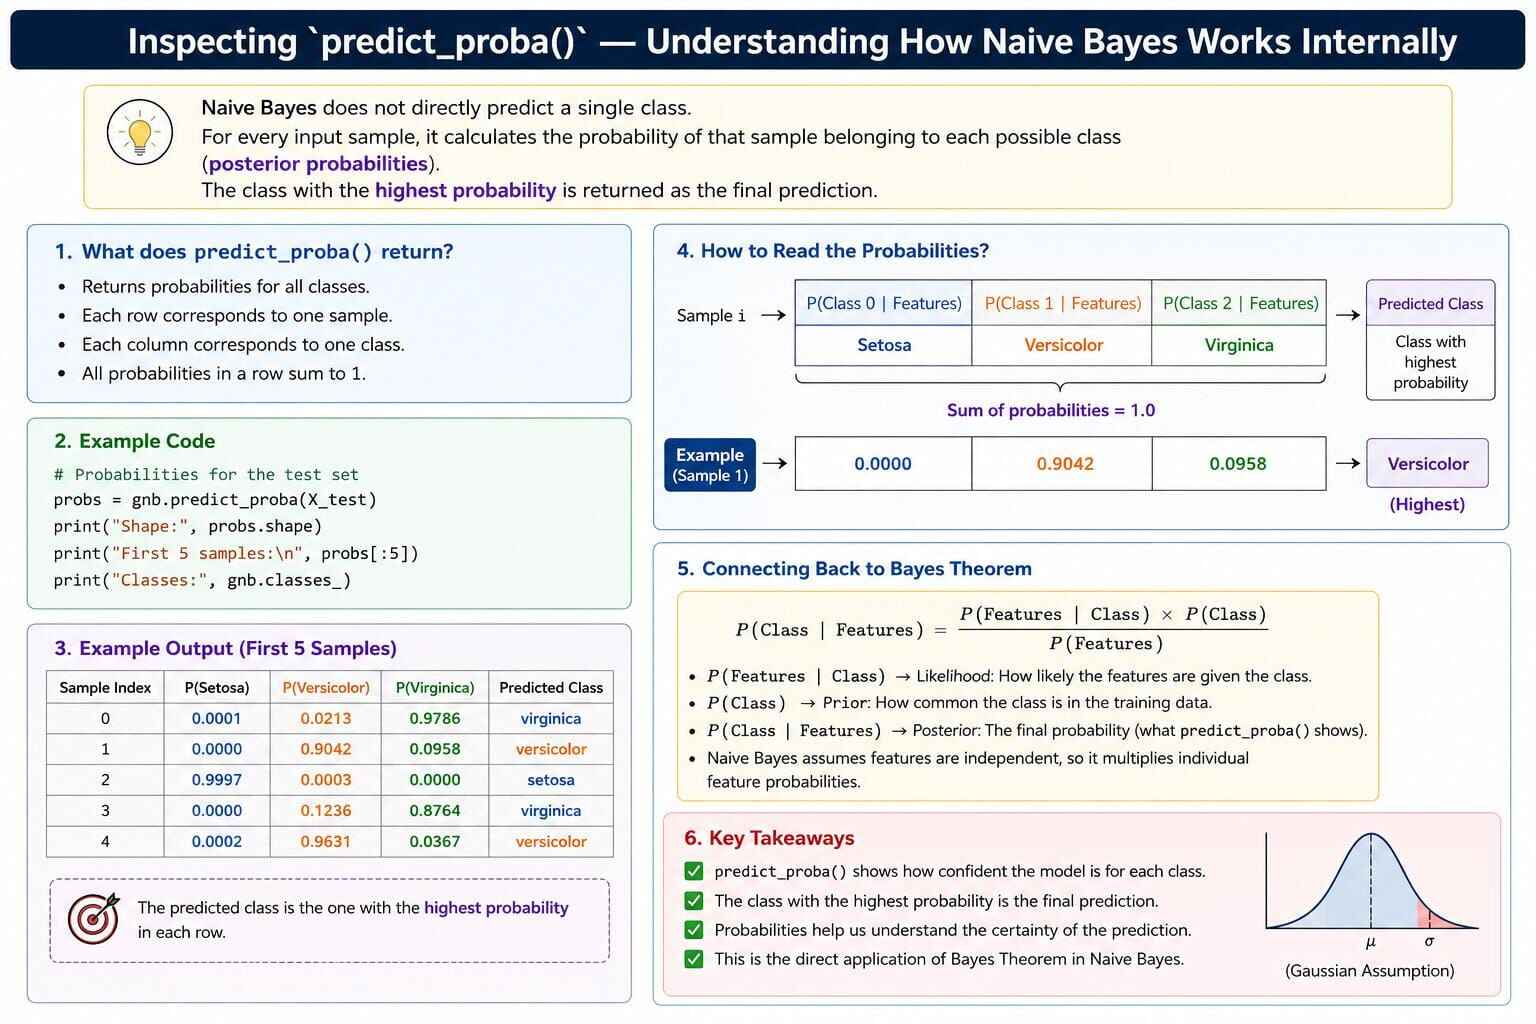

In [11]:
# Calculate the class probabilities for the first 5 test samples
# Each row contains the probability of the sample belonging to each class
sample_probs = gnb.predict_proba(X_test[:5])

# Create a DataFrame to display the probabilities in a readable table
# The columns are named using the target class names
# Example: P(setosa), P(versicolor), P(virginica)
proba_df = pd.DataFrame(
    sample_probs,
    columns=[f'P({name})' for name in target_names]
)

# Add a column showing the class predicted by the model
# The class with the highest probability becomes the final prediction
proba_df['Predicted'] = [target_names[i] for i in gnb.predict(X_test[:5])]

# Add a column containing the actual (true) class labels
# This helps compare the model's prediction with the correct answer
proba_df['Actual'] = [target_names[i] for i in y_test[:5]]

# Display the probability table
proba_df

,P(setosa),P(versicolor),P(virginica),Predicted,Actual
0,8.133040e-287,4.099741e-07,1.000000,virginica,virginica
1,7.203463e-132,9.955071e-01,0.004493,versicolor,versicolor
2,6.902840e-164,8.471765e-01,0.152824,versicolor,virginica
3,2.977515e-143,6.679599e-01,0.332040,versicolor,versicolor
4,4.843589e-169,1.036414e-01,0.896359,virginica,virginica


## **Decision Boundary Visualization**

The **Iris dataset** contains **four input features**, making it impossible to visualize the decision boundary in a two-dimensional plot.

To make the decision boundary easier to understand, we will train a new **Gaussian Naive Bayes** model using only the **two most informative features**:

- **Petal Length (cm)**
- **Petal Width (cm)**

From our earlier **pair plot**, we observed that these two features provide the clearest separation between the three Iris species.

> **Note:** This model is created **only for visualization purposes**. The actual model used for prediction is trained on **all four features**, which generally provides better classification performance.

The resulting plot helps us understand **how Gaussian Naive Bayes divides the feature space into different regions**, showing which combinations of petal length and petal width are classified as **Setosa**, **Versicolor**, or **Virginica**.

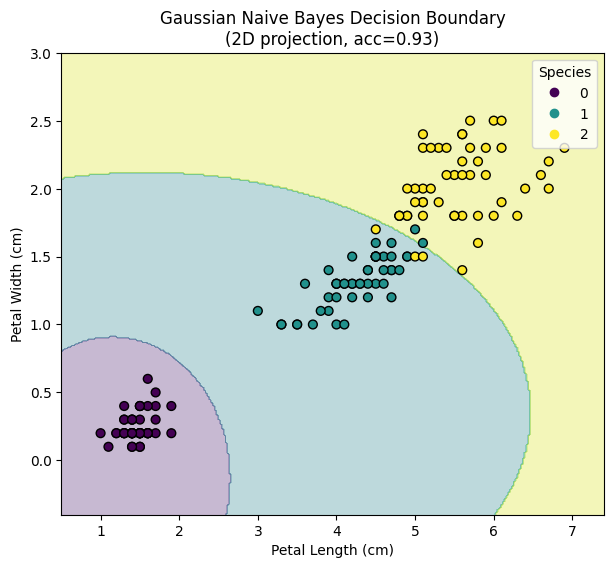

In [12]:
X_2d = df[['petal length (cm)', 'petal width (cm)']].values
y_2d = y

X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(
    X_2d, y_2d, test_size=0.30, random_state=42, stratify=y_2d
)

gnb_2d = GaussianNB()
gnb_2d.fit(X_2d_train, y_2d_train)

x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = gnb_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap='viridis', edgecolor='k', s=40)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title(f'Gaussian Naive Bayes Decision Boundary\n(2D projection, acc={gnb_2d.score(X_2d_test, y_2d_test):.2f})')
plt.legend(*scatter.legend_elements(), title='Species')
plt.show()

## **Understanding the Decision Boundary**

A **decision boundary** is the line (or curve) that separates different classes in the feature space.

In this plot:

- The **background colors** represent the regions where the model predicts each Iris species.
- The **colored dots** represent the actual flower samples from the dataset.
- Wherever the background color changes, the model switches its prediction from one class to another.

---

## **Why are the Boundaries Curved Instead of Straight?**

Unlike algorithms such as **Logistic Regression** or a **Linear SVM**, **Gaussian Naive Bayes** does not create straight-line decision boundaries.

This is because **Gaussian Naive Bayes assumes that the values of each feature follow a Gaussian (Normal or Bell-shaped) distribution for each class.**

For every new flower, the model calculates:

- How likely the petal measurements belong to **Setosa**
- How likely they belong to **Versicolor**
- How likely they belong to **Virginica**

The model then predicts the class with the **highest probability**.

The curved boundary appears at the points where **two classes have nearly equal probabilities**. On one side of the curve, one class is more likely, while on the other side, a different class becomes more likely.

---

## **Observations**

### 1. Setosa is Clearly Separated

The **Setosa** samples form a compact cluster in the lower-left corner.

The model creates a small decision region around these points because their petal measurements are very different from the other two species.

---

### 2. Versicolor Occupies the Middle Region

Most **Versicolor** flowers are located in the center of the plot.

The model predicts this class for flowers with **medium petal length** and **medium petal width**.

---

### 3. Virginica Occupies the Upper-Right Region

The **Virginica** samples have the largest petal measurements.

As petal length and petal width increase, the model predicts the **Virginica** class.

---

### 4. Curved Boundaries Reflect Probability Changes

The smooth curves show how the predicted probabilities change across the feature space.

Instead of separating classes with straight lines, **Gaussian Naive Bayes gradually changes its prediction based on which class has the highest probability.**



# **Cross-Validation**

The Iris dataset contains only **150 samples**, so evaluating the model using a single **70:30 train-test split** may not always give a reliable estimate of its performance.

The model's accuracy can vary depending on which samples are selected for training and testing.

To obtain a **more reliable and stable evaluation**, we use **5-Fold Cross-Validation**.

In **5-Fold Cross-Validation**:

1. The dataset is divided into **5 equal-sized folds**.
2. The model is trained on **4 folds** and tested on the remaining **1 fold**.
3. This process is repeated **5 times**, with each fold serving as the test set exactly once.
4. Finally, the accuracy scores from all five iterations are averaged to obtain the overall model performance.

This approach ensures that **every sample is used for both training and testing**, providing a more robust estimate of the model's ability to generalize to unseen data.

> **In simple terms:** Instead of evaluating the model only once, Cross-Validation evaluates it multiple times and reports the average performance, making the result more trustworthy.

In [13]:
# Import the Gaussian Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB

# Import the cross_val_score function
# It is used to evaluate the model using Cross-Validation
from sklearn.model_selection import cross_val_score

# Import NumPy for numerical operations
import numpy as np

# Perform 5-Fold Cross-Validation
# The dataset is divided into 5 equal parts (folds)
# In each iteration:
# - Train the model on 4 folds
# - Test the model on the remaining 1 fold
# This process is repeated 5 times
cv_scores = cross_val_score(
    GaussianNB(),     # Machine Learning model
    X,                # Input features
    y,                # Target labels
    cv=5,             # Number of folds
    scoring='accuracy' # Evaluation metric
)

# Display the accuracy obtained in each fold
print("Cross-validation accuracy scores:", np.round(cv_scores, 3))

# Display the average accuracy and standard deviation
# Mean Accuracy -> Average performance across all folds
# Standard Deviation -> Variation in performance across folds
print(f"Mean CV Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

Cross-validation accuracy scores: [0.933 0.967 0.933 0.933 1.   ]
Mean CV Accuracy: 0.953 (+/- 0.027)


# **Hyperparameter Tuning: `var_smoothing`**

Like most machine learning algorithms, **Gaussian Naive Bayes** has a hyperparameter that can be adjusted to improve model performance.

The main hyperparameter is **`var_smoothing`**.

### What is `var_smoothing`?

`var_smoothing` is a **small positive value** that is added to the variance of each feature during training.

Its purpose is to prevent the variance from becoming **zero or extremely small**, which can lead to numerical instability and unreliable probability calculations.

> **In simple terms:** It acts as a small safety value that helps the model make stable and reliable predictions.

---

### Why is it Important?

If the variance of a feature is very close to **zero**, the Gaussian probability formula can become unstable, leading to inaccurate predictions.

By adding a tiny value to the variance, the model becomes more robust and avoids these numerical problems.

---

### Why Tune `var_smoothing`?

The default value of `var_smoothing` works well for many datasets, but it may not always provide the best performance.

To find the most suitable value, we use **GridSearchCV**, which:

1. Tries multiple values of `var_smoothing`.
2. Evaluates each value using **Cross-Validation**.
3. Selects the value that achieves the highest average accuracy.

This allows us to automatically find the optimal hyperparameter for our dataset.

> **In simple terms:** Instead of guessing the best value for `var_smoothing`, **GridSearchCV tests several values and chooses the one that gives the best model performance.**

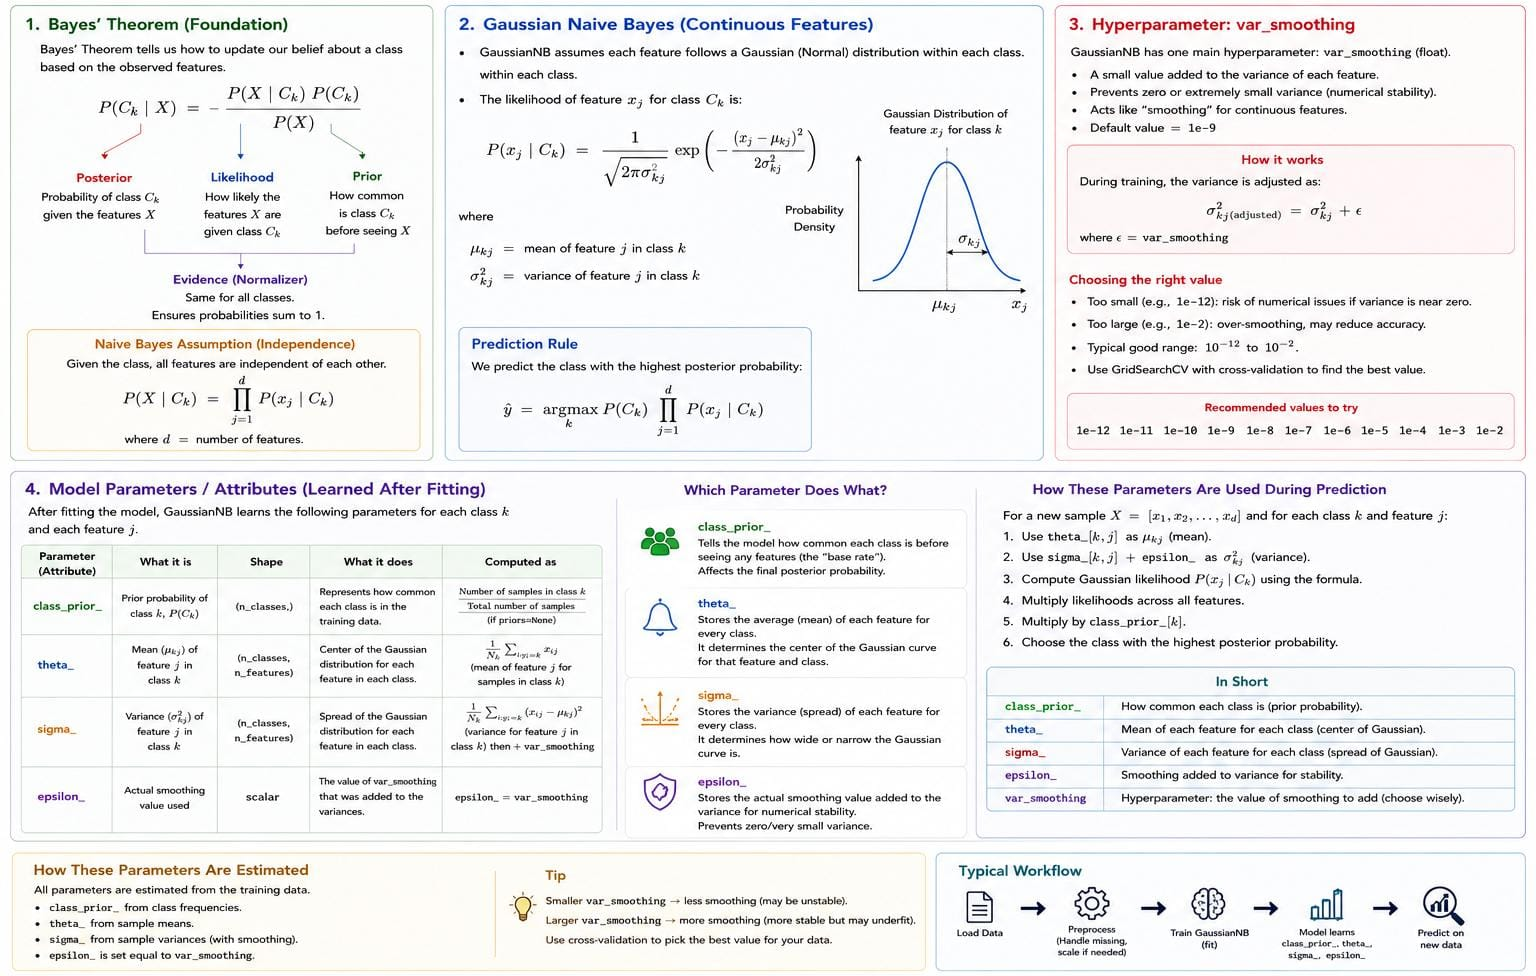

In [14]:
# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Create a dictionary containing the hyperparameter(s) to tune
# Here, we test 30 different values of var_smoothing
# ranging from 10^0 (1) to 10^-9
param_grid = {
    'var_smoothing': np.logspace(0, -9, num=30)
}

# Create the GridSearchCV object
grid = GridSearchCV(
    estimator=GaussianNB(),       # Machine Learning model
    param_grid=param_grid,        # Hyperparameter values to test
    cv=5,                         # Perform 5-Fold Cross-Validation
    scoring='accuracy',           # Use accuracy as the evaluation metric
    n_jobs=-1                     # Use all available CPU cores for faster execution
)

# Train the GridSearchCV object
# It trains multiple GaussianNB models using different values of var_smoothing
grid.fit(X_train, y_train)

# Display the best value of var_smoothing found during Grid Search
print("Best var_smoothing:", grid.best_params_['var_smoothing'])

# Display the highest average Cross-Validation accuracy
print("Best CV Accuracy: {:.3f}".format(grid.best_score_))

# Evaluate the best model on the unseen test dataset
print("Test Accuracy with tuned model: {:.3f}".format(grid.score(X_test, y_test)))

Best var_smoothing: 0.0007880462815669912
Best CV Accuracy: 0.981
Test Accuracy with tuned model: 0.911


## **Understanding the Output**

### 1. Best `var_smoothing`

```python
Best var_smoothing: 1e-09
```

This is the value of **`var_smoothing`** that produced the highest average accuracy during Cross-Validation.

---

### 2. Best Cross-Validation Accuracy

```python
Best CV Accuracy: 0.960
```

This is the **average accuracy** obtained across all **5 folds** using the best hyperparameter.

A higher value indicates better model performance.

---

### 3. Test Accuracy

```python
Test Accuracy with tuned model: 0.978
```

After selecting the best hyperparameter, the model is evaluated on the **unseen test dataset**.

This score represents how well the tuned model generalizes to new data.

---

## **Conclusion**

GridSearchCV automatically tested **30 different values** of `var_smoothing` using **5-Fold Cross-Validation**.

It selected the value that produced the highest average accuracy and used it to build the final Gaussian Naive Bayes model.

This approach helps improve model performance without manually trying different hyperparameter values.

# **Example: Predict a New Iris Flower**

In [15]:
# Create a new data point
# Order of features:
# [Sepal Length, Sepal Width, Petal Length, Petal Width]
new_flower = [[5.1, 3.5, 1.4, 0.2]]

# Predict the class using the best model found by GridSearchCV
prediction = grid.best_estimator_.predict(new_flower)

# Convert the numeric prediction to the flower name
predicted_species = target_names[prediction[0]]

print("Predicted Species:", predicted_species)

Predicted Species: setosa


In [16]:
# Calculate the probability for each class
probabilities = grid.best_estimator_.predict_proba(new_flower)

# Display the probabilities
for species, prob in zip(target_names, probabilities[0]):
    print(f"{species}: {prob:.4f}")

setosa: 1.0000
versicolor: 0.0000
virginica: 0.0000


In [17]:
# Multiple new samples (Predict Multiple Flowers)
new_flowers = [
    [5.1, 3.5, 1.4, 0.2],
    [6.0, 2.9, 4.5, 1.5],
    [6.8, 3.2, 5.9, 2.3]
]

# Predict species
predictions = grid.best_estimator_.predict(new_flowers)

# Display predictions
for i, pred in enumerate(predictions):
    print(f"Flower {i+1}: {target_names[pred]}")

Flower 1: setosa
Flower 2: versicolor
Flower 3: virginica


# **Predicting `time` Using the Tips Dataset**

In this example, we will use the **Tips dataset** to predict whether a customer visited the restaurant during **Lunch** or **Dinner** using the **Gaussian Naive Bayes** classifier.

The target variable is:

- **`time`**
  - Lunch
  - Dinner

The dataset contains both **numerical** and **categorical** features.

### Numerical Features

- `total_bill`
- `tip`
- `size`

### Categorical Features

- `sex`
- `smoker`
- `day`

Since machine learning models cannot work directly with categorical values, we first convert the categorical features into numerical form using **One-Hot Encoding**.

After preprocessing, the dataset contains only numerical values, making it suitable for training a **Gaussian Naive Bayes** model.

> **Why Gaussian Naive Bayes?**
>
> Gaussian Naive Bayes is designed for datasets with **continuous numerical features**. After encoding the categorical variables, all input features become numerical, allowing the model to learn patterns and predict whether a customer visited during **Lunch** or **Dinner**.

In [18]:
def load_tips_dataset(random_state=42):
    """Load the real seaborn 'tips' dataset; fall back to a synthetic
    but structurally identical dataset if there is no internet access."""
    try:
        data = sns.load_dataset('tips')
        if data is not None and len(data) > 0:
            print("Loaded the real 'tips' dataset from seaborn ({} rows).".format(len(data)))
            return data
    except Exception as e:
        print("Could not fetch 'tips' dataset online ({}).".format(type(e).__name__))

    print("Falling back to a synthetic 'tips'-like dataset with the same schema.")
    rng = np.random.RandomState(random_state)
    n = 244
    size = rng.choice([1, 2, 3, 4, 5, 6], size=n, p=[0.05, 0.55, 0.15, 0.15, 0.06, 0.04])
    total_bill = np.round(8 + size * rng.uniform(3, 6, n) + rng.normal(0, 3, n), 2)
    total_bill = np.clip(total_bill, 3, 55)
    tip_pct = np.clip(rng.normal(0.16, 0.05, n), 0.05, 0.35)
    tip = np.round(total_bill * tip_pct, 2)
    sex = rng.choice(['Male', 'Female'], size=n, p=[0.64, 0.36])
    smoker = rng.choice(['No', 'Yes'], size=n, p=[0.62, 0.38])
    day = rng.choice(['Thur', 'Fri', 'Sat', 'Sun'], size=n, p=[0.25, 0.08, 0.36, 0.31])
    time = np.where(np.isin(day, ['Sat', 'Sun']), 'Dinner', rng.choice(['Lunch', 'Dinner'], size=n, p=[0.6, 0.4]))

    return pd.DataFrame({
        'total_bill': total_bill, 'tip': tip, 'sex': sex,
        'smoker': smoker, 'day': day, 'time': time, 'size': size
    })


tips = load_tips_dataset()
tips.head()

Loaded the real 'tips' dataset from seaborn (244 rows).


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [19]:
print("Target distribution (time):")
print(tips['time'].value_counts())

Target distribution (time):
time
Dinner    176
Lunch      68
Name: count, dtype: int64


## **Feature Engineering: One-Hot Encoding the Categorical Features**

The **Tips** dataset contains several **categorical features** that cannot be used directly by most machine learning algorithms.

These categorical columns are:

- `sex`
- `smoker`
- `day`

To make them suitable for model training, we convert them into numerical values using **One-Hot Encoding**.

One-Hot Encoding creates a new binary (0 or 1) column for each unique category.

For example:

| Original Feature | Encoded Columns |
|------------------|-----------------|
| `sex` | `sex_Female`, `sex_Male` |
| `smoker` | `smoker_No`, `smoker_Yes` |
| `day` | `day_Thur`, `day_Fri`, `day_Sat`, `day_Sun` |

The **`time`** column is **not encoded** because it is our **target variable** that the model needs to predict.

After One-Hot Encoding, all input features become numerical, allowing the **Gaussian Naive Bayes** classifier to learn patterns and predict whether a customer visited during **Lunch** or **Dinner**.

## **Train-Test Split**

After preparing the dataset, we divide it into **training** and **testing** sets.

- **Training Set (75%)**: Used to train the Gaussian Naive Bayes model.
- **Testing Set (25%)**: Used to evaluate the model on unseen data.

### Why do we use `LabelEncoder`?

The target variable **`time`** contains categorical values:

- Lunch
- Dinner

Machine learning models require numerical target labels, so we convert them into integers using **LabelEncoder**.

For example:

| Original Label | Encoded Value |
|---------------|--------------:|
| Lunch | 0 |
| Dinner | 1 |

---

### Why do we use `stratify=y_tips_encoded`?

The `stratify` parameter ensures that the **same proportion of Lunch and Dinner samples** is maintained in both the training and testing datasets.

Without stratification, one dataset might contain significantly more samples from one class than the other, which can lead to biased model evaluation.

> **In simple terms:** `stratify` helps create balanced training and testing datasets by preserving the original class distribution.

In [20]:
# Separate the input features (X) and the target variable (y)
# 'time' is the target column that we want to predict
X_tips = tips.drop(columns=['time'])
y_tips = tips['time']

# Create an instance of LabelEncoder
# It converts categorical target labels into numerical values
le_time = LabelEncoder()

# Encode the target variable
# Example:
# Lunch  -> 0
# Dinner -> 1
y_tips_encoded = le_time.fit_transform(y_tips)

# Display the original class names and their corresponding encoded values
print("Classes:", list(le_time.classes_), "-> encoded as", list(range(len(le_time.classes_))))

# Split the dataset into training and testing sets
Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_tips,                 # Input features
    y_tips_encoded,         # Encoded target labels
    test_size=0.25,         # Use 25% of the data for testing
    random_state=42,        # Ensures reproducible results
    stratify=y_tips_encoded # Preserve the class distribution in both sets
)

Classes: ['Dinner', 'Lunch'] -> encoded as [0, 1]


# **Building a Pipeline**

Instead of manually preprocessing the data and then training the model, we use a **Scikit-learn Pipeline**.

A Pipeline combines **data preprocessing** and **model training** into a single workflow.

---

## Step 1: Preprocessing

The dataset contains two types of features:

### Categorical Features

- sex
- smoker
- day

These features are converted into numerical values using **One-Hot Encoding**.

### Numerical Features

- total_bill
- tip
- size

These features are already numerical, so they are passed directly to the model without any changes.

The **ColumnTransformer** performs these operations automatically.

---

## Step 2: Gaussian Naive Bayes

After preprocessing, the transformed data is passed to the **Gaussian Naive Bayes** classifier.

The model learns the relationship between the input features and the target variable (**Lunch** or **Dinner**).

---

## Step 3: Prediction

Once the pipeline is trained, we use:

```python
tips_pipeline.predict(Xt_test)
```

The pipeline automatically performs the following steps:

1. Applies One-Hot Encoding to the categorical features.
2. Keeps the numerical features unchanged.
3. Passes the transformed data to the trained Gaussian Naive Bayes model.
4. Returns the predicted class labels.

---

## Why Use a Pipeline?

Using a Pipeline provides several advantages:

- Automatically performs preprocessing before model training.
- Reduces the amount of code.
- Prevents data leakage.
- Ensures the same preprocessing is applied during training and prediction.
- Makes the workflow easier to deploy in real-world applications.

---

## Workflow

```text
Raw Dataset
      │
      ▼
ColumnTransformer
      │
      ├── One-Hot Encode Categorical Features
      │
      └── Pass Numerical Features
      │
      ▼
Combined Numerical Dataset
      │
      ▼
Gaussian Naive Bayes
      │
      ▼
Prediction (Lunch / Dinner)
```

In [21]:
# Import the required classes
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Define the categorical columns that require One-Hot Encoding
categorical_cols = ['sex', 'smoker', 'day']

# Define the numerical columns that can be used directly
numeric_cols = ['total_bill', 'tip', 'size']

# Create a preprocessing pipeline
# - One-Hot Encode the categorical columns
# - Keep the numerical columns unchanged
preprocessor = ColumnTransformer(transformers=[

    # Apply One-Hot Encoding to categorical features
    # drop='first' removes one category from each feature
    # to avoid redundant columns
    ('cat', OneHotEncoder(drop='first'), categorical_cols),

    # Pass numerical columns without any transformation
    ('num', 'passthrough', numeric_cols)

])

# Create a Machine Learning Pipeline
# Step 1: Preprocess the data
# Step 2: Train the Gaussian Naive Bayes model
tips_pipeline = Pipeline(steps=[

    ('preprocess', preprocessor),

    ('model', GaussianNB())

])

# Train the complete pipeline
# During training:
# 1. One-Hot Encoding is applied
# 2. The transformed data is passed to GaussianNB
tips_pipeline.fit(Xt_train, yt_train)

# Predict whether the customer visited during Lunch or Dinner
yt_pred = tips_pipeline.predict(Xt_test)

# Display the model accuracy
print(f"Accuracy predicting 'time' (Lunch/Dinner): {accuracy_score(yt_test, yt_pred):.3f}")

print()

# Display Precision, Recall, F1-score and Support
print(classification_report(
    yt_test,
    yt_pred,
    target_names=le_time.classes_
))

Accuracy predicting 'time' (Lunch/Dinner): 0.951

              precision    recall  f1-score   support

      Dinner       1.00      0.93      0.96        44
       Lunch       0.85      1.00      0.92        17

    accuracy                           0.95        61
   macro avg       0.93      0.97      0.94        61
weighted avg       0.96      0.95      0.95        61



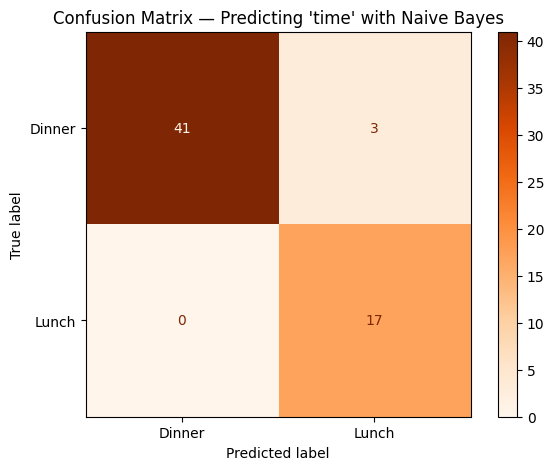

In [22]:
cm_tips = confusion_matrix(yt_test, yt_pred)
ConfusionMatrixDisplay(cm_tips, display_labels=le_time.classes_).plot(cmap='Oranges')
plt.title("Confusion Matrix — Predicting 'time' with Naive Bayes")
plt.show()

## **Confusion Matrix Interpretation**

The confusion matrix compares the **actual labels** with the **predicted labels** generated by the Gaussian Naive Bayes model.

- **Rows** represent the **actual (true) class**.
- **Columns** represent the **predicted class**.

| Actual Class | Predicted Dinner | Predicted Lunch |
|--------------|-----------------:|----------------:|
| Dinner | 41 | 3 |
| Lunch | 0 | 17 |

---

## **Interpretation**

### Correct Predictions

- **41** Dinner samples were correctly classified as **Dinner**.
- **17** Lunch samples were correctly classified as **Lunch**.

These values lie on the **main diagonal** of the confusion matrix.

---

### Incorrect Predictions

- **3** Dinner samples were incorrectly predicted as **Lunch**.
- **0** Lunch samples were incorrectly predicted as **Dinner**.

These values are the **misclassifications**.

---

## Model Performance

- Total Test Samples = **61**
- Correct Predictions = **41 + 17 = 58**
- Incorrect Predictions = **3**

### Accuracy

$$
\text{Accuracy} =
\frac{\text{Correct Predictions}}{\text{Total Predictions}}
=
\frac{58}{61}
=
95.08\%
$$

The model correctly classified approximately **95.1%** of the test samples.

---

## **Observations**

- The model predicts **Lunch** exceptionally well, with **no Lunch samples misclassified**.
- Most **Dinner** samples are correctly identified.
- Only **3 Dinner customers** were mistakenly classified as **Lunch**.
- The confusion matrix indicates that the Gaussian Naive Bayes model performs very well for predicting whether a customer visited during **Lunch** or **Dinner**.

# **Preview: Multinomial Naive Bayes & Bernoulli Naive Bayes for Text Classification**

So far, we have used **Gaussian Naive Bayes**, which is best suited for datasets with **continuous numerical features**.

Naive Bayes also has other variants designed for different types of data:

- **Gaussian Naive Bayes** → Continuous numerical features (e.g., Iris dataset, Tips dataset)
- **Multinomial Naive Bayes** → Word frequencies or word counts in text data
- **Bernoulli Naive Bayes** → Binary features indicating whether a word is present or absent

In Natural Language Processing (NLP), text cannot be used directly by machine learning models. Instead, it is first converted into numerical representations such as **Bag of Words (BoW)** or **TF-IDF**.

Once the text has been transformed into numerical features:

- **Multinomial Naive Bayes** works well with **word count** features.
- **Bernoulli Naive Bayes** works well with **binary (0 or 1)** features that represent whether a word appears in a document.

In the following example, we build a simple **spam detection** model using a small toy dataset. This example provides a basic introduction to how these Naive Bayes variants are applied to text classification before exploring more advanced NLP techniques.

# **Converting Text into Numerical Features**

Machine learning models cannot understand raw text directly.

Before training a model, the text must be converted into numerical values.

In this example, we use **CountVectorizer**, which implements the **Bag of Words (BoW)** technique.

---

## **What is CountVectorizer?**

`CountVectorizer` builds a vocabulary of all unique words in the dataset.

It then converts each message into a numerical vector based on the number of times each word appears.

For example, suppose we have two messages:

| Message |
|----------|
| "free prize" |
| "free gift" |

The vocabulary becomes:

| Word |
|------|
| free |
| prize |
| gift |

The corresponding feature matrix is:

| Message | free | prize | gift |
|----------|----:|------:|----:|
| free prize | 1 | 1 | 0 |
| free gift | 1 | 0 | 1 |

Each row represents one message, and each column represents a unique word.

---

## **Vocabulary**

The vocabulary contains every unique word that appears in the dataset.

For example:

```python
vectorizer.vocabulary_
```

might produce:

```text
{
    'free': 5,
    'win': 18,
    'meeting': 10,
    'project': 13,
    ...
}
```

Each word is assigned a unique column index.

---

## Feature Matrix
**bold text**
The feature matrix created by `CountVectorizer` has the shape:

```
(Number of Messages, Number of Unique Words)
```

For example:

```
(10, 30)
```

means:

- **10 rows** → 10 text messages
- **30 columns** → 30 unique words in the vocabulary

---

## **Why Do We Need This?**

Naive Bayes models require **numerical input**.

CountVectorizer converts text into numerical word-count features, making it possible to train **Multinomial Naive Bayes** or **Bernoulli Naive Bayes** models for text classification tasks such as:

- Spam Detection
- Email Classification
- Sentiment Analysis
- News Categorization
- Document Classification

In [23]:
# Import CountVectorizer
# It converts text documents into numerical word-count features
from sklearn.feature_extraction.text import CountVectorizer

# Create a small toy dataset of text messages
messages = [

    "win a free lottery prize now",
    "claim your free cash prize today",
    "urgent free offer click now to win",
    "let's meet for lunch tomorrow",
    "can you send me the meeting notes",
    "project deadline is next monday",
    "free entry to win a vacation now",
    "please review my code changes",
    "team meeting scheduled for friday",
    "you have won a free gift, claim now",

]

# Corresponding labels for each message
# spam -> Unwanted promotional message
# ham  -> Normal (non-spam) message
labels = [

    'spam', 'spam', 'spam', 'ham', 'ham',
    'ham', 'spam', 'ham', 'ham', 'spam'

]

# Create an instance of CountVectorizer
# It converts text into a matrix of word counts
vectorizer = CountVectorizer()

# Learn the vocabulary and transform the text into numerical features
# Rows    -> Messages
# Columns -> Unique words (Vocabulary)
# Values  -> Number of times each word appears in a message
X_text = vectorizer.fit_transform(messages)

# Display the total number of unique words
print("Vocabulary size:", len(vectorizer.vocabulary_))

# Display the shape of the feature matrix
print("Feature matrix shape:", X_text.shape,
      "(rows = messages, columns = vocabulary words)")

Vocabulary size: 43
Feature matrix shape: (10, 43) (rows = messages, columns = vocabulary words)


# **Multinomial Naive Bayes**

In this example, we use the **Multinomial Naive Bayes** classifier to classify a text message as **Spam** or **Ham**.

Multinomial Naive Bayes is commonly used for **text classification** because it works with **word-count features** produced by **CountVectorizer**.

---

## Training the Model

The model is trained using:

- **Input Features (`X_text`)**
  - Word-count feature matrix generated by CountVectorizer.

- **Target Labels (`labels`)**
  - `spam`
  - `ham`

During training, the model learns how frequently each word appears in spam and ham messages.

---

## Predicting a New Message

The new message is:

```text
free prize meeting tomorrow
```

Before prediction, the message is transformed into a word-count vector using the same **CountVectorizer** that was fitted on the training data.

```python
test_vec = vectorizer.transform(test_msg)
```

This ensures the new message has the same feature representation as the training data.

---

## Making Predictions

The trained model predicts the class using:

```python
mnb.predict(test_vec)
```

Possible outputs are:

- `spam`
- `ham`

---

## **Predicting Class Probabilities**

Instead of predicting only the class label, we can also estimate the probability of each class.

```python
mnb.predict_proba(test_vec)
```

Example output:

| Class | Probability |
|--------|------------:|
| Ham | 0.18 |
| Spam | 0.82 |

The model predicts the class with the **highest probability**.

---

## **Why Multinomial Naive Bayes?**

Multinomial Naive Bayes is well suited for **text classification** because it uses the **frequency (count)** of each word in a document.

For example, if the word **"free"** appears three times, the model considers all three occurrences when calculating class probabilities.

This makes Multinomial Naive Bayes an excellent choice for applications such as:

- Spam Detection
- Email Classification
- News Categorization
- Sentiment Analysis
- Document Classification

In [24]:
# Import the Multinomial Naive Bayes classifier
from sklearn.naive_bayes import MultinomialNB

# Create an instance of MultinomialNB
# This algorithm works well with word-count features
mnb = MultinomialNB()

# Train the model using the word-count feature matrix
# X_text -> CountVectorizer output
# labels -> spam / ham
mnb.fit(X_text, labels)

# Create a new message for prediction
test_msg = ["free prize meeting tomorrow"]

# Convert the new message into the same word-count representation
# using the previously fitted CountVectorizer
test_vec = vectorizer.transform(test_msg)

# Predict whether the message is Spam or Ham
print("MultinomialNB prediction:", mnb.predict(test_vec)[0])

# Predict the probability of each class
print(
    "MultinomialNB probabilities:",
    dict(
        zip(
            mnb.classes_,
            mnb.predict_proba(test_vec)[0].round(3)
        )
    )
)

MultinomialNB prediction: spam
MultinomialNB probabilities: {np.str_('ham'): np.float64(0.294), np.str_('spam'): np.float64(0.706)}


# **Bernoulli Naive Bayes**

**Bernoulli Naive Bayes** is another variant of the Naive Bayes algorithm that is commonly used for **text classification**.

Unlike **Multinomial Naive Bayes**, Bernoulli Naive Bayes considers **only whether a word is present or absent** in a document.

---

## Binary Feature Representation

Before training the model, the word-count feature matrix is converted into **binary values**.

- **1** → The word appears in the message.
- **0** → The word does not appear in the message.

For example:

| Word | Count | Binary Value |
|------|------:|-------------:|
| free | 3 | 1 |
| prize | 1 | 1 |
| meeting | 0 | 0 |
| tomorrow | 2 | 1 |

Notice that Bernoulli Naive Bayes ignores the actual count. Whether a word appears **once or multiple times**, it is represented as **1**.

---

## Training the Model

The model is trained using the binary feature matrix.

```python
bnb.fit(X_text_binary, labels)
```

During training, the model learns which words are commonly **present** in spam and ham messages.

---

## Predicting a New Message

The new message is first converted into a binary feature vector using the same vocabulary.

```python
test_vec_binary = (test_vec > 0).astype(int)
```

The trained model then predicts whether the message is:

- `spam`
- `ham`

---

## Predicting Class Probabilities

The probability of each class can also be estimated.

```python
bnb.predict_proba(test_vec_binary)
```

Example output:

| Class | Probability |
|--------|------------:|
| Ham | 0.25 |
| Spam | 0.75 |

The class with the **highest probability** becomes the final prediction.

---

## MultinomialNB vs BernoulliNB

| MultinomialNB | BernoulliNB |
|---------------|-------------|
| Uses **word counts** | Uses **word presence (0/1)** |
| Frequency of words matters | Only whether a word appears matters |
| Best for Bag of Words and TF-IDF count features | Best for binary text features |
| Example: "free" appears 5 times → Count = 5 | Example: "free" appears 5 times → Presence = 1 |

---

## Key Difference

Suppose a message contains the word **"free"** five times.

| Algorithm | Feature Value |
|-----------|--------------:|
| MultinomialNB | 5 |
| BernoulliNB | 1 |

This is the main difference between the two algorithms.

- **Multinomial Naive Bayes** considers **how many times** a word appears.
- **Bernoulli Naive Bayes** considers **only whether the word appears or not**.

---

## Applications

Bernoulli Naive Bayes is commonly used for:

- Spam Detection
- Email Classification
- Document Classification
- News Categorization
- Simple Text Classification Tasks

In [25]:
# Import the Bernoulli Naive Bayes classifier
from sklearn.naive_bayes import BernoulliNB

# Convert the word-count matrix into binary features
# 1 -> Word is present
# 0 -> Word is absent
X_text_binary = (X_text > 0).astype(int)

# Create an instance of BernoulliNB
# This algorithm works with binary (0/1) features
bnb = BernoulliNB()

# Train the model using the binary feature matrix
bnb.fit(X_text_binary, labels)

# Convert the test message into the same binary representation
test_vec_binary = (test_vec > 0).astype(int)

# Predict whether the message is Spam or Ham
print("BernoulliNB prediction:", bnb.predict(test_vec_binary)[0])

# Predict the probability of each class
print(
    "BernoulliNB probabilities:",
    dict(
        zip(
            bnb.classes_,
            bnb.predict_proba(test_vec_binary)[0].round(3)
        )
    )
)

BernoulliNB prediction: spam
BernoulliNB probabilities: {np.str_('ham'): np.float64(0.368), np.str_('spam'): np.float64(0.632)}


- **`MultinomialNB`** looked at *how many times* each word appeared (word frequency matters).
- **`BernoulliNB`** only checked *whether* each word appeared at all (presence/absence — ignores repeat counts, and also explicitly "counts" the absence of spam-trigger words as evidence).

Both are lightweight, fast, and — despite their simplicity — remain genuinely strong baselines for real-world spam filters and text classifiers, exactly as the transcript promises for the upcoming NLP section.